# Assignment 6 — Real-Data Weather and Climate Trend Analysis
Authentic NASA POWER gridded daily estimates for the 25-field South Carolina cluster; no network access is used here.

In [1]:
from pathlib import Path
import hashlib,json,pandas as pd
from IPython.display import display,Image
ROOT=next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/'data/assignment-06').exists())
A=ROOT/'data/assignment-06'; S=A/'source'; O=A/'output'

## Source provenance and checksum validation

In [2]:
m=json.loads((S/'source_manifest.json').read_text()); raw=S/'nasa_power_daily_raw.json'
assert m['status']=='success' and m['no_synthetic_fallback'] and hashlib.sha256(raw.read_bytes()).hexdigest()==m['raw_response']['sha256']
display(pd.DataFrame([m['request']]))

,acquisition_method,community,endpoint,externally_downloaded_and_locally_imported,format,http_status,imported_from,no_synthetic_fallback,parameters,raw_response_byte_count,raw_response_sha256,requested_coordinates,requested_date_range,requested_to_returned_distance_km,response_content_type,retrieval_timestamp_utc,returned_grid_coordinates,sorted_query_parameters,time_standard
0,external_raw_import,AG,https://power.larc.nasa.gov/api/temporal/daily...,True,JSON,None,/home/hemanthd95/Downloads/nasa_power_daily_ra...,True,"[ALLSKY_SFC_SW_DWN, PRECTOTCORR, RH2M, T2M, T2...",1272254,cebf64e8481161fe51c5c98745989e1b304bbf0e8526e9...,"{'latitude': 34.33090814412706, 'longitude': -...","{'end': '2025-12-31', 'start': '1991-01-01'}",0.010913,application/json (validated local bytes),2026-07-29T23:15:34.937611+00:00,"{'latitude': 34.331, 'longitude': -82.536}","{'community': 'AG', 'end': '20251231', 'format...",LST


## Field and weather-point context
The acreage-weighted centroid is one representative point. NASA POWER is gridded and cannot resolve field-to-field meteorological differences or replace an on-site station.

In [3]:
loc=json.loads((S/'field_location_summary.json').read_text()); dist=pd.read_csv(S/'field_to_weather_point_distances.csv',dtype={'field_id':str}); assert len(dist)==25 and dist.field_id.nunique()==25; display(loc,dist.head())

{'cluster_extent': {'east': -82.52188923445452,
  'east_west_span_m': 2699.0249820562312,
  'north': 34.34843152355022,
  'north_south_span_m': 3363.715664222371,
  'south': 34.31788880370307,
  'west': -82.55090481818236},
 'distance_m': {'maximum': 2198.680847167236,
  'mean': 834.8211352402316,
  'median': 655.7930892606566,
  'minimum': 93.02842436609292,
  'standard_deviation': 544.713931685182},
 'field_count': 25,
 'limitation': 'One gridded series represents the overall cluster and does not resolve field-to-field meteorological differences.',
 'representative_latitude': 34.33090814412706,
 'representative_longitude': -82.53604244635059}

,field_id,field_acres,field_centroid_x_utm,field_centroid_y_utm,field_centroid_longitude,field_centroid_latitude,distance_to_weather_point_m,crop_2023
0,451623001001160,4.233174,359944.976051,3.801725e+06,-82.522765,34.347391,2198.680847,Grassland/Pasture
1,451623001001187,2.941068,359783.688254,3.800967e+06,-82.524394,34.340530,1512.437854,Grassland/Pasture
2,451623001001196,17.514312,359567.920982,3.800870e+06,-82.526723,34.339625,1292.256541,Other Hay/Non Alfalfa
3,451623001001204,3.307537,359711.924720,3.800651e+06,-82.525122,34.337673,1253.945823,Grassland/Pasture
4,451623001001218,6.187809,358924.979418,3.800439e+06,-82.533640,34.335658,571.271243,Grassland/Pasture


## Daily structure and data quality
Fill values are missing, never interpolated. Hot (≥35 °C maximum), frost (≤0 °C minimum), dry (<1 mm), and heavy-rain (≥25 mm) flags are descriptive—not universal crop-injury thresholds.

In [4]:
daily=pd.read_csv(O/'tables/weather_daily_1991_2025.csv',parse_dates=['date']); quality=pd.read_csv(O/'tables/weather_data_quality.csv'); assert len(daily)==12784; display(daily.head(),quality)

,date,year,month,month_name,day_of_year,t2m_mean_C,t2m_max_C,t2m_min_C,diurnal_temperature_range_C,precipitation_mm,relative_humidity_pct,solar_radiation_kWh_m2_day,is_complete_weather_day,hot_day_ge_35C,frost_day_le_0C,dry_day_lt_1mm,heavy_rain_day_ge_25mm
0,1991-01-01,1991,1,Jan,1,2.75,6.52,-1.12,7.64,0.53,83.60,5.98,True,False,True,True,False
1,1991-01-02,1991,1,Jan,2,6.63,13.40,2.59,10.81,1.14,90.22,9.24,True,False,False,False,False
2,1991-01-03,1991,1,Jan,3,5.86,8.20,4.06,4.14,2.97,96.80,2.83,True,False,False,False,False
3,1991-01-04,1991,1,Jan,4,5.24,10.82,1.65,9.17,0.21,86.02,3.83,True,False,False,True,False
4,1991-01-05,1991,1,Jan,5,5.29,8.19,2.84,5.35,0.48,87.68,3.46,True,False,False,True,False


,parameter,expected_record_count,observed_record_count,valid_record_count,missing_record_count,missing_percentage,minimum,maximum,mean,median,units,fill_value,first_valid_date,last_valid_date
0,T2M,12784,12784,12784,0,0.0,-11.46,33.11,16.186974,16.84,C,-999,1991-01-01,2025-12-31
1,T2M_MAX,12784,12784,12784,0,0.0,-5.77,42.88,22.507232,23.26,C,-999,1991-01-01,2025-12-31
2,T2M_MIN,12784,12784,12784,0,0.0,-19.66,25.72,10.599698,11.14,C,-999,1991-01-01,2025-12-31
3,PRECTOTCORR,12784,12784,12784,0,0.0,0.00,108.64,3.504434,0.34,mm/day,-999,1991-01-01,2025-12-31
4,RH2M,12784,12784,12784,0,0.0,28.69,99.36,75.521283,75.86,%,-999,1991-01-01,2025-12-31
5,ALLSKY_SFC_SW_DWN,12784,12784,12784,0,0.0,0.87,31.43,16.379291,16.68,MJ/m^2/day,-999,1991-01-01,2025-12-31


## Aggregation rules
Temperature and humidity/radiation are means; precipitation is accumulated. Months need ≥90% valid days. Dry spells reset at annual and April–October boundaries.

In [5]:
monthly=pd.read_csv(O/'tables/weather_monthly_1991_2025.csv'); annual=pd.read_csv(O/'tables/weather_annual_1991_2025.csv'); warm=pd.read_csv(O/'tables/weather_warm_season_1991_2025.csv'); assert len(monthly)==420 and len(annual)==35; display(monthly.head(),annual.tail())

,year,month,expected_days,valid_days,completeness_pct,is_complete_period,mean_temperature_C,mean_max_temperature_C,mean_min_temperature_C,mean_diurnal_range_C,precipitation_mm,mean_relative_humidity_pct,mean_solar_radiation_kWh_m2_day,hot_day_count,frost_day_count,dry_day_count,heavy_rain_day_count,longest_dry_spell_days
0,1991,1,31,31,100.0,True,4.794839,9.827419,0.484194,9.343226,149.36,87.725484,7.767097,0,14,16,1,4
1,1991,2,28,28,100.0,True,7.201786,13.080357,1.943214,11.137143,79.84,80.231786,12.076429,0,10,17,0,5
2,1991,3,31,31,100.0,True,11.085484,16.954839,5.388710,11.566129,181.73,82.740000,15.065484,0,4,18,2,8
3,1991,4,30,30,100.0,True,16.686000,22.444000,11.558667,10.885333,145.52,83.195667,17.340333,0,0,13,0,5
4,1991,5,31,31,100.0,True,21.876129,26.904839,17.044194,9.860645,152.35,83.157097,18.189355,0,0,9,0,4


,year,expected_days,valid_days,completeness_pct,is_complete_period,annual_mean_temperature_C,mean_max_temperature_C,mean_min_temperature_C,mean_diurnal_range_C,annual_precipitation_mm,mean_relative_humidity_pct,mean_solar_radiation_kWh_m2_day,hot_day_count,frost_day_count,dry_day_count,heavy_rain_day_count,longest_dry_spell_days
30,2021,365,365,100.0,True,16.520137,22.794658,11.017836,11.776822,1209.55,76.593534,16.451753,16,44,230,8,15
31,2022,365,365,100.0,True,16.620110,23.261233,10.832384,12.428849,1199.03,72.918411,16.738356,34,53,224,12,13
32,2023,365,365,100.0,True,17.082575,23.507479,11.460384,12.047096,1199.64,74.024247,16.471260,23,30,231,10,23
33,2024,366,366,100.0,True,17.248415,23.651175,11.704508,11.946667,1366.01,75.574481,16.636585,37,44,235,14,28
34,2025,365,365,100.0,True,16.532521,23.086274,10.861123,12.225151,1104.84,74.042575,16.727589,28,59,232,7,16


## Seasonal climatology — baseline 1991–2020

,month,mean_t2m_C,mean_t2m_max_C,mean_t2m_min_C,t2m_p10_C,t2m_p90_C,mean_monthly_precipitation_mm,median_monthly_precipitation_mm,precipitation_p10_mm,precipitation_p90_mm,mean_relative_humidity_pct,mean_solar_radiation_kWh_m2_day,mean_hot_day_count,mean_dry_day_count
0,1,4.710366,10.541172,-0.155462,2.196323,7.672968,117.603333,123.470,63.149,168.922,82.541097,9.564075,0.000000,20.033333
1,2,6.677046,12.715771,1.380374,4.686571,8.614536,108.369333,102.215,53.167,166.503,81.640489,12.079033,0.000000,18.300000
2,3,10.787151,17.100495,4.950441,8.183903,13.368613,118.987667,108.975,62.966,182.292,79.762226,15.913688,0.000000,20.100000
3,4,15.679422,22.018667,9.482589,13.953033,17.299500,97.481000,89.590,48.002,149.210,77.706433,20.079822,0.000000,19.866667
4,5,20.603785,26.663419,14.704204,18.797194,22.143355,96.546333,88.825,53.424,152.905,75.508849,22.195688,0.133333,18.533333
5,6,24.945411,31.010022,19.271978,23.486867,26.970267,114.383333,107.480,54.205,171.527,72.344822,22.958033,3.833333,12.700000
6,7,27.119108,33.452624,21.377086,25.608000,28.617839,110.044667,91.495,65.555,160.816,69.485280,22.097774,10.533333,12.066667
7,8,26.293129,32.752452,20.635645,24.223355,27.820935,115.775667,118.525,54.032,183.131,69.569989,20.100183,7.766667,13.666667
8,9,22.723878,29.394711,17.128411,21.159433,24.634667,101.689667,92.585,45.503,156.134,70.497289,17.404744,1.666667,19.400000
9,10,16.519151,23.474581,10.636570,15.092968,18.051935,89.652333,84.355,27.450,151.794,72.451366,14.262237,0.133333,23.366667


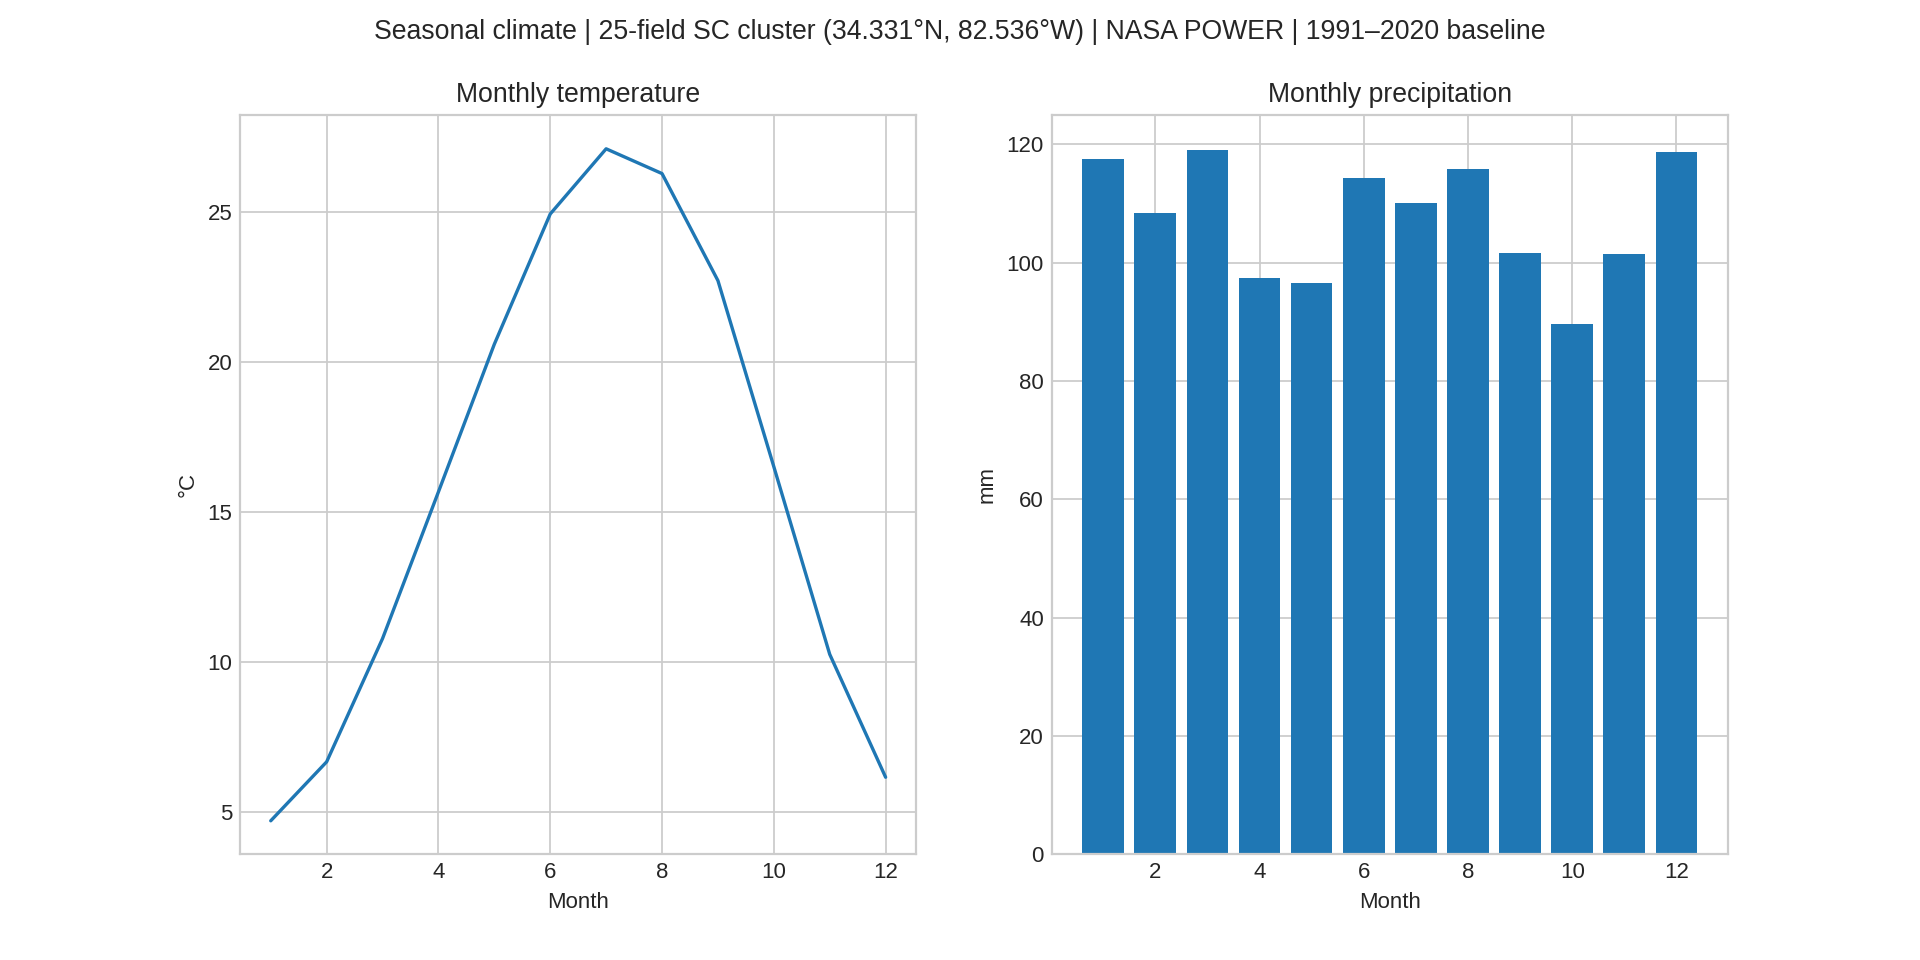

In [6]:
normals=pd.read_csv(O/'tables/climate_normals_1991_2020.csv'); display(normals); display(Image(filename=str(O/'dashboard_assets/dashboard_seasonal_climate.png')))

## Trends and precipitation anomalies

,metric,n_complete_years,ols_slope_per_year,ols_slope_per_decade,ols_intercept,pearson_r,r_squared,ols_p_value,ols_standard_error,ols_slope_ci95_low,ols_slope_ci95_high,theil_sen_slope_per_year,theil_sen_slope_per_decade,theil_sen_ci95_low,theil_sen_ci95_high,kendall_tau,kendall_p_value,alpha,ols_significant,kendall_significant
0,annual_mean_temperature_C,35,0.048533,0.485334,-81.268087,0.658470,0.433583,0.000017,0.009656,0.028887,0.068180,0.049247,0.492466,0.025925,0.070501,0.448739,0.000150,0.05,True,True
1,annual_precipitation_mm,35,-2.598938,-25.989384,6498.687972,-0.117102,0.013713,0.502898,3.836853,-10.405075,5.207198,-3.458276,-34.582759,-11.886667,6.392941,-0.072269,0.541424,0.05,False,False
2,warm_season_mean_temperature_C,35,0.039430,0.394298,-57.132241,0.499416,0.249416,0.002256,0.011907,0.015205,0.063655,0.039512,0.395124,0.011840,0.067957,0.324370,0.006128,0.05,True,True
3,warm_season_precipitation_mm,35,0.131104,1.311036,460.682459,0.008816,0.000078,0.959914,2.588719,-5.135684,5.397891,0.261304,2.613043,-5.604286,6.186923,0.011765,0.920813,0.05,False,False
4,hot_day_count,35,0.295518,2.955182,-568.829132,0.183129,0.033536,0.292343,0.276161,-0.266337,0.857373,0.368421,3.684211,-0.214286,0.928571,0.155040,0.195369,0.05,False,False
5,warm_season_longest_dry_spell_days,35,0.063305,0.633053,-111.317087,0.109117,0.011907,0.532647,0.100389,-0.140938,0.267549,0.043478,0.434783,-0.095238,0.208333,0.078308,0.520132,0.05,False,False


,year,annual_mean_temperature_C,annual_mean_temperature_C_anomaly,annual_mean_temperature_C_zscore,annual_mean_temperature_C_notable,annual_precipitation_mm,annual_precipitation_mm_anomaly,annual_precipitation_mm_zscore,annual_precipitation_mm_notable,annual_precipitation_mm_anomaly_pct,warm_season_mean_temperature_C,warm_season_mean_temperature_C_anomaly,warm_season_mean_temperature_C_zscore,warm_season_mean_temperature_C_notable,warm_season_precipitation_mm,warm_season_precipitation_mm_anomaly,warm_season_precipitation_mm_zscore,warm_season_precipitation_mm_notable,warm_season_precipitation_mm_anomaly_pct
0,2021,16.520137,0.435462,0.573261,False,1209.55,-81.170667,-0.335358,False,-6.288786,21.963411,-0.032157,-0.037641,False,752.12,26.547,0.163525,False,3.658763
1,2022,16.620110,0.535434,0.704869,False,1199.03,-91.690667,-0.378822,False,-7.103835,22.348832,0.353263,0.413504,False,609.28,-116.293,-0.716346,False,-16.027746
2,2023,17.082575,0.997900,1.313680,False,1199.64,-91.080667,-0.376301,False,-7.056575,21.972150,-0.023419,-0.027413,False,666.78,-58.793,-0.362155,False,-8.102975
3,2024,17.248415,1.163740,1.531999,False,1366.01,75.289333,0.311059,False,5.833124,22.917336,0.921768,1.078955,False,729.37,3.797,0.023389,False,0.523311
4,2025,16.532521,0.447845,0.589563,False,1104.84,-185.880667,-0.767969,False,-14.401309,22.431075,0.435506,0.509772,False,813.11,87.537,0.539214,False,12.064534


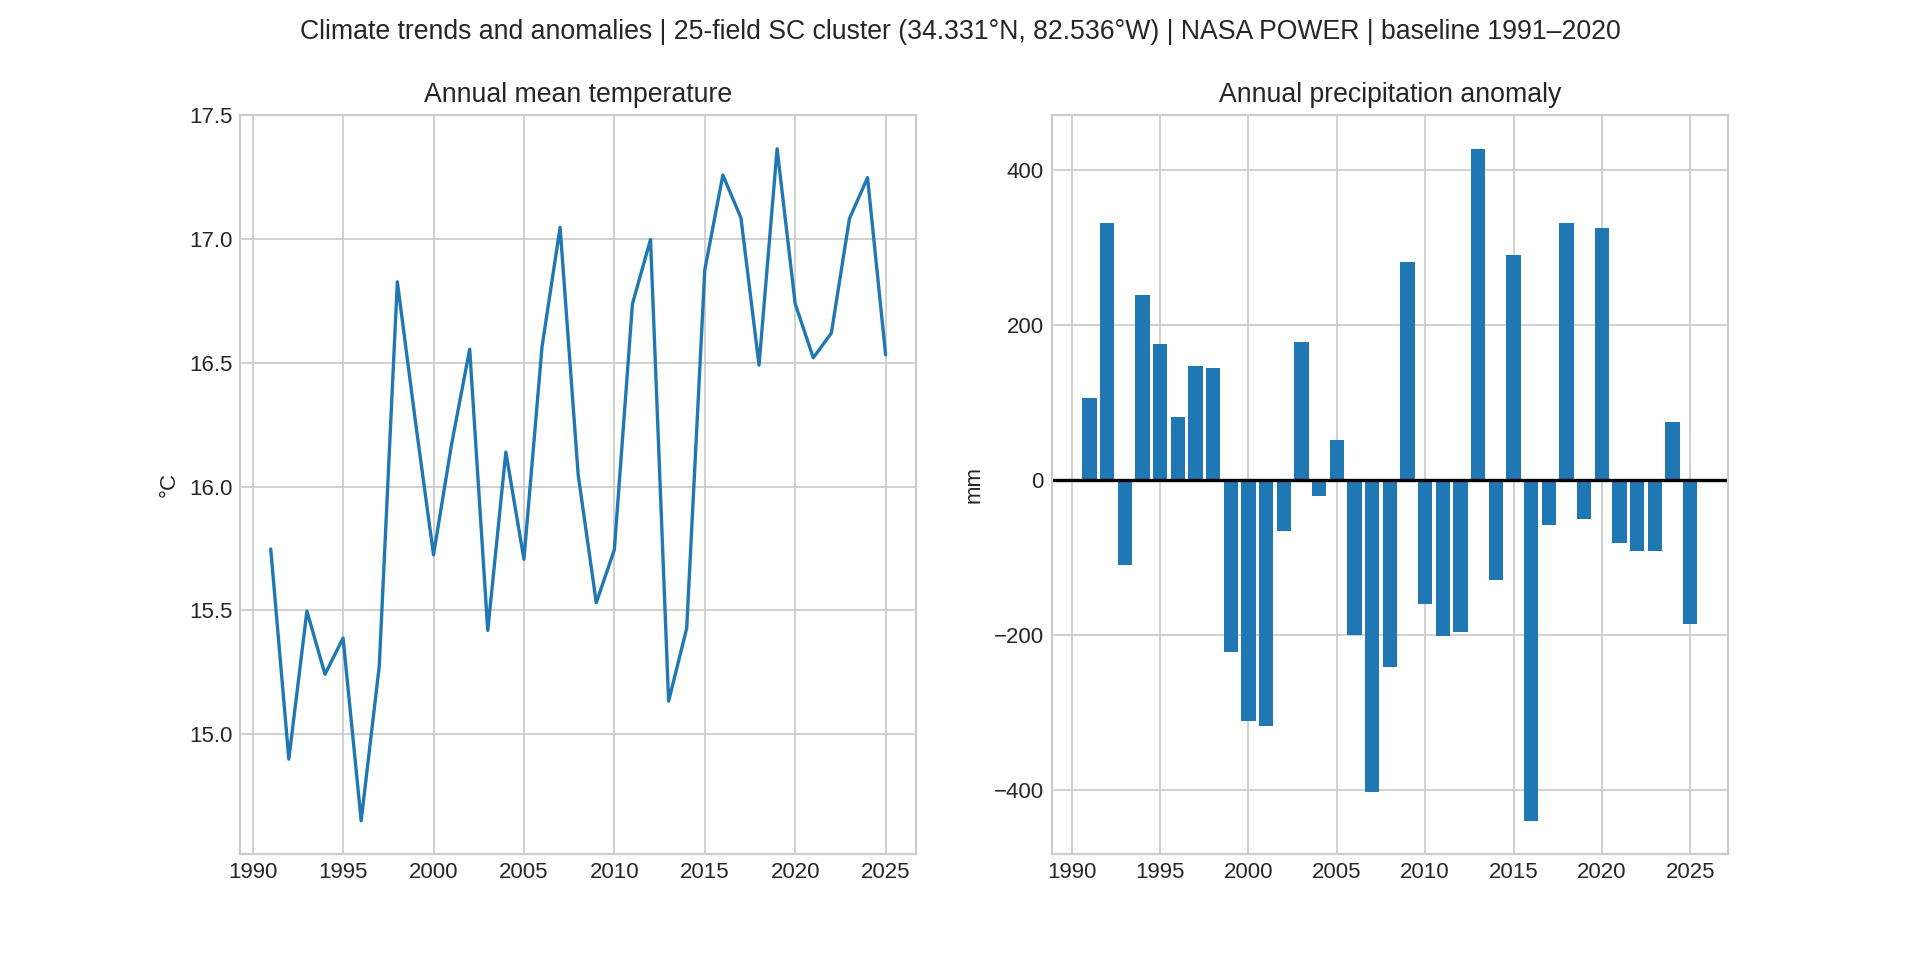

In [7]:
trends=pd.read_csv(O/'tables/climate_trend_statistics.csv'); anomalies=pd.read_csv(O/'tables/climate_anomalies_1991_2025.csv'); recent=pd.read_csv(O/'tables/recent_anomalies_2021_2025.csv'); display(trends,recent); display(Image(filename=str(O/'dashboard_assets/dashboard_climate_trends_anomalies.png')))

## Warm-season weather-risk metrics
April–October is a consistent agricultural analytical window, not every crop’s exact phenology. Metrics support planning context but do not establish crop damage or causation.

In [8]:
display(warm[['year','warm_season_hot_day_count','warm_season_longest_dry_spell_days','warm_season_precipitation_mm']].tail(10))

,year,warm_season_hot_day_count,warm_season_longest_dry_spell_days,warm_season_precipitation_mm
25,2016,52,23,484.11
26,2017,13,25,867.41
27,2018,4,13,886.26
28,2019,45,15,652.69
29,2020,16,11,895.70
30,2021,16,13,752.12
31,2022,34,13,609.28
32,2023,23,23,666.78
33,2024,37,28,729.37
34,2025,28,12,813.11


## Independent internal validation and interpretation cautions
Trends are local and descriptive; statistical significance is not agronomic importance or global attribution. Gridded NASA estimates are not station measurements.

In [9]:
assert daily.date.is_unique and daily.date.is_monotonic_increasing
assert daily.date.min()==pd.Timestamp('1991-01-01') and daily.date.max()==pd.Timestamp('2025-12-31')
assert (daily.diurnal_temperature_range_C-(daily.t2m_max_C-daily.t2m_min_C)).abs().max()<1e-9
assert set(recent.year)==set(range(2021,2026))
print('All notebook internal assertions passed.')

All notebook internal assertions passed.
